# Handling Categorical Missing Data

## Two methods of Imputing missing data :
1. Imputing with the most frequent value
2. Missing category

## 1. Imputing with the most frequent value

Missing values are replaced with the Mode of the variable, but only when the follwoing conditions are true : 
- MCAR
- <5% values are missing
- The difference between the freq. of the mode value and the rest of the values must be significantly large. 

### Advantages :
- Easy to implement and recreate in production environment


### Disadvantages 
- Distribution of varuable changes

## 2. Missing category

In this technique, a new category 'missing' is created and replaces all the nan values.
Used when : 
- Data is NCAR
- 5%> values are missing

### Advantages 
- Easy and simple

### Disadvantages 
- Introduces randomness into the variable

## Other Missing Value Imputation Methods 
1. Random Value Imputation
2. Missing Indicator Imputation
3. Automatically select best imputation

## 1. Random Value Imputation
Missing values are replaced by values randomly chosed from the values of the variable. 
- Randomly selection of any of the values of the variable and replace the missing values.
- Can be applied to **both** - numerical and categorical data 

### Advantages 
- Easy to implement (though no sklearn support)
- Preserves the distribution and variance of the variable
- Well suited for linear models, as it does not distort the distribution


### Disadvantages
- Memory heavy for deplaoyment, since we need to store the original training dataset to extract values from and replace the incoming NaN values
- Does not perform very well with models like decision trees

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [36]:
df = pd.read_csv('../../3_eda/titanic.csv', usecols=[ 'Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [38]:
#Train-test split
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [39]:
# Create new col of ages to apply changes to and compare afterwards
X_train['Age_new'] = X_train['Age']
X_test['Age_new'] = X_test['Age']
X_train.sample(5)

,Age,Fare,Age_new
271,25.0,0.0000,25.0
134,25.0,13.0000,25.0
410,NaN,7.8958,NaN
429,32.0,8.0500,32.0
85,33.0,15.8500,33.0


In [40]:
# Replace missing values by random vals
# LHS : Selecting those vals from X_train['Age_new'] where X_train['Age_new'] values are null i.e., missing
X_train.loc[X_train['Age_new'].isnull(), 'Age_new'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
# RHS : 1. drop the null values so you don't replace a null value with another null value
#2. fetch as many random values (using sample) as there are null values (isnull().sum()) .values fetches the values

X_train.sample(10)

,Age,Fare,Age_new
505,18.0,108.9000,18.0
634,9.0,27.9000,9.0
22,15.0,8.0292,15.0
764,16.0,7.7750,16.0
738,NaN,7.8958,62.0
400,39.0,7.9250,39.0
373,22.0,135.6333,22.0
258,35.0,512.3292,35.0
827,1.0,37.0042,1.0
397,46.0,26.0000,46.0


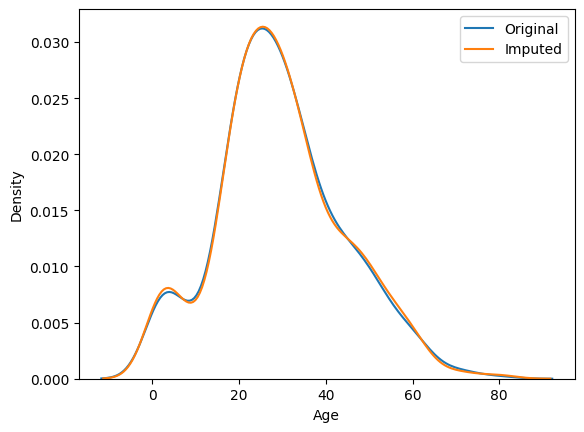

In [29]:
# Checking the distribution
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_new'], label='Imputed')

plt.legend()
plt.show()

##### They overlap 

### Variance

In [30]:
print("Original variance : ", X_train['Age'].var())
print("Imputed variance : ", X_train['Age_new'].var())

Original variance :  210.2517072477435
Imputed variance :  213.35748177989535


Very slight difference, only as much as seen in the plot

#### Covariance

In [32]:
X_train.cov()

,Age,Fare,Age_new
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,68.251670
Age_new,210.251707,68.251670,213.357482


### Note : ensure that for the same input , same output is generated i.e., same random value is selected for same input (look it up)

## 2. Missing Indicator Imputation
For each variable with missing values, a corresponsing, boolean missing values variable is created which indicates whether the corresponsing value in the variable is null or not.
- 0 -> value NOT missing
- 1 -> value missing

Improves performance of the model as it learns to differentiate between missing and non-missing values => improved accuracy/r2score.

Implemented using MissingIndicator() from sklearn or through SimpleImputer(add_indicator=True)

### 3. Automatic best value selection for imputation
- Sklearn uses grid search cv algo to compare all the techniques and returns the best one.